# 02 · Weibull analysis
Fit a Weibull distribution to the pumps' time to first failure.
- Input: `data/failure_times.csv` (from notebook 01)
- Output: `data/weibull_params.json` (β, η, R²)

## Method: median-rank regression

The Weibull distribution gives the probability that a pump has failed by time $t$:

$$F(t) = 1 - e^{-(t/\eta)^{\beta}}$$

- $\eta$ (scale, characteristic life): time by which 63.2% of pumps have failed
- $\beta$ (shape): $\beta < 1$ early failures, $\beta = 1$ random failures, $\beta > 1$ wear-out

Taking logs twice turns this into a straight line:

$$\ln\ln\frac{1}{1-F} = \beta \ln t - \beta \ln \eta$$

So plotting $y = \ln\ln\frac{1}{1-F}$ against $x = \ln t$ gives a line with slope $\beta$ and intercept $b = -\beta \ln \eta$, which means

$$\eta = e^{-b/\beta}$$

$F$ is not observed directly, so it is estimated for each failure from its position among all pumps:

| Step | Formula |
|---|---|
| Rank | position when sorted by time ($1 \dots n$) |
| Reversed rank | $n - \text{rank} + 1$ |
| Adjusted rank (Johnson) | $\text{adj}_i = \text{adj}_{i-1} + \dfrac{n + 1 - \text{adj}_{i-1}}{1 + \text{reversed rank}_i}$, for failures only |
| Median rank (Bernard) | $F_i = \dfrac{\text{adj}_i - 0.3}{n + 0.4}$ |

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pm_optimization as pm
import matplotlib.pyplot as plt

# Colours and a clean default style shared by all the figures below
TEAL, GREY, RED = "#00534d", "#9AA5B1", "#C0392B"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

# One row per pump: hours to first failure (failed = 1), or to the end of
# the window if the pump never failed (failed = 0, a suspension)
data = pd.read_csv(pm.FAILURE_TIMES)
print(len(data), "pumps")
data["failed"].value_counts()

99 pumps


failed
0    52
1    47
Name: count, dtype: int64

## Median-rank table
The steps above applied to the pump data (first rows shown). Every suspension sits at the end of the window, after all the failures, so here the adjusted rank ends up equal to the plain rank.

In [2]:
# Failures only: suspensions take part in the ranking but are not plotted
table = pm.median_rank_table(data["hours"], data["failed"])
table[["hours", "rank", "reversed_rank", "adj_rank", "median_rank", "ln_t", "ln_ln"]].head(8).round(4)

,hours,rank,reversed_rank,adj_rank,median_rank,ln_t,ln_ln
0,840.0,1,99,1.0,0.0070,6.7334,-4.9523
1,840.0,2,98,2.0,0.0171,6.7334,-4.0599
2,1704.0,3,97,3.0,0.0272,7.4407,-3.5922
3,2064.0,4,96,4.0,0.0372,7.6324,-3.2719
4,3528.0,5,95,5.0,0.0473,8.1685,-3.0275
5,3672.0,6,94,6.0,0.0573,8.2085,-2.8293
6,3696.0,7,93,7.0,0.0674,8.2150,-2.6624
7,3768.0,8,92,8.0,0.0775,8.2343,-2.5179


## Fit
A straight line $y = \beta x + b$ is fitted through the points $(\ln t,\ \ln\ln\frac{1}{1-F})$.
The slope is $\beta$, and the scale is recovered as $\eta = e^{-b/\beta}$.
$R^2$ measures how close the points lie to a straight line, i.e. how well a Weibull describes the data.

In [3]:
fit = pm.fit_weibull_mrr(data["hours"], data["failed"])
print(f"β  = {fit['beta']:.4f}")
print(f"η  = {fit['eta_hours']:,.0f} hours ({fit['eta_hours'] / pm.HOURS_PER_MONTH:.1f} months)")
print(f"R² = {fit['r2']:.4f}")

β  = 1.1466
η  = 36,173 hours (49.5 months)
R² = 0.9703


## Reliability over the current PM interval

In [4]:
# The pumps are currently serviced every 6 months
t_pm = 6 * pm.HOURS_PER_MONTH
print(f"Reliability over a 6-month interval: {pm.reliability(t_pm, fit['beta'], fit['eta_hours']):.2%}")

Reliability over a 6-month interval: 91.50%


## Save
Store the fitted parameters for the next notebook. `save_params` also adds η in months.

In [5]:
pm.save_params(fit)
print(pm.WEIBULL_PARAMS.read_text())

{
  "beta": 1.1465773914889534,
  "eta_hours": 36172.50125474466,
  "intercept": -12.034538761214332,
  "r2": 0.9702681894182917,
  "n_units": 99,
  "n_failures": 47,
  "eta_months": 49.54594188958013
}


## Weibull probability plot
If the data follow a Weibull distribution, the points lie on a straight line. The slope of the fitted line is $\beta$.

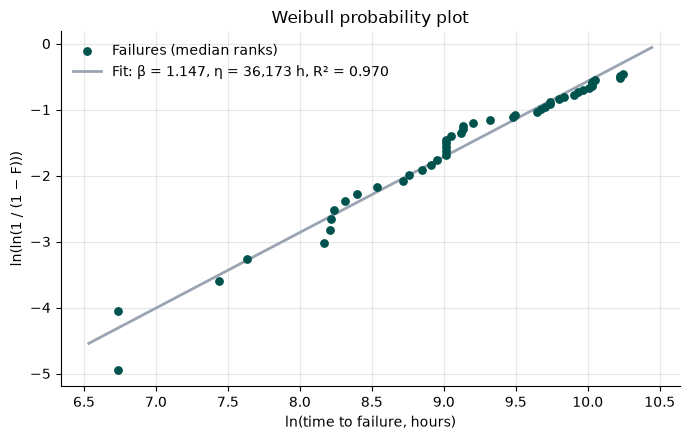

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
# One point per failure, at its median-rank plotting position
ax.scatter(table["ln_t"], table["ln_ln"], s=28, color=TEAL, label="Failures (median ranks)", zorder=3)

# Fitted line y = β·x + b, drawn a little past the data on both sides
x_line = np.linspace(table["ln_t"].min() - 0.2, table["ln_t"].max() + 0.2, 100)
ax.plot(x_line, fit["beta"] * x_line + fit["intercept"], color=GREY, lw=2,
        label=f"Fit: β = {fit['beta']:.3f}, η = {fit['eta_hours']:,.0f} h, R² = {fit['r2']:.3f}")

ax.set(xlabel="ln(time to failure, hours)", ylabel="ln(ln(1 / (1 − F)))", title="Weibull probability plot")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(pm.FIG_DIR / "weibull_probability_plot.png", dpi=200)
plt.show()

## Reliability curves
The probability density $f(t)$ shows when failures are most likely. The cumulative failure probability $F(t)$ reaches 63.2% at the characteristic life $\eta$.

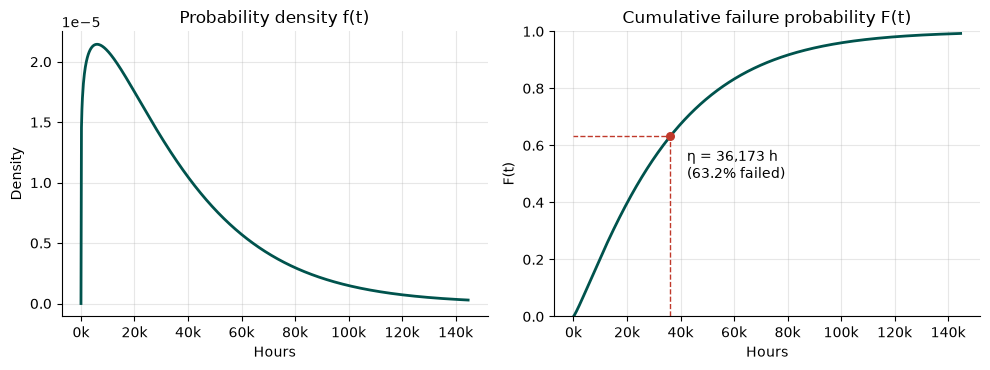

In [7]:
beta, eta = fit["beta"], fit["eta_hours"]
t = np.linspace(0, 4 * eta, 800)
# Weibull density f(t) = (β/η)(t/η)^(β-1) exp(-(t/η)^β), over 0 to 4η
pdf = (beta / eta) * (t / eta) ** (beta - 1) * np.exp(-(t / eta) ** beta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

ax1.plot(t, pdf, color=TEAL, lw=2)
ax1.set(title="Probability density f(t)", xlabel="Hours", ylabel="Density")

ax2.plot(t, pm.failure_prob(t, beta, eta), color=TEAL, lw=2)
# Mark the characteristic life: F(η) = 1 - e^-1 = 63.2% for any β
ax2.plot([eta, eta, 0], [0, 0.632, 0.632], color=RED, lw=1, ls="--")
ax2.scatter([eta], [0.632], color=RED, s=30, zorder=3)
ax2.annotate(f"η = {eta:,.0f} h\n(63.2% failed)", (eta, 0.632), xytext=(12, -30), textcoords="offset points")
ax2.set(title="Cumulative failure probability F(t)", xlabel="Hours", ylabel="F(t)", ylim=(0, 1))

# Show hours in thousands (e.g. 40k) to keep the axes readable
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))

fig.tight_layout()
fig.savefig(pm.FIG_DIR / "weibull_pdf_cdf.png", dpi=200)
plt.show()